# Day 24 - Dimensionality Reduction with PCA
60 Days Data Science | Phase: Dimensionality Reduction

**Date:** 06 June 2026  
**Name:** Rajesh Yadav


## Step 1 - Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)

print("numpy  :", np.__version__)
print("pandas :", pd.__version__)


numpy  : 2.2.1
pandas : 2.2.3


## Step 2 - Load and Preprocess Dataset

In [2]:
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'telco_customer_churn.csv'

df_raw = pd.read_csv(dataset_path)
print(f"Raw shape: {df_raw.shape}")

# Preprocessing
df = df_raw.copy()
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

# One-hot encode categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

X_all = df_enc.drop(columns=['Churn'])
y_all = df_enc['Churn']

# Standardize the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=X_all.columns)

print(f"Encoded and scaled features shape: {X_scaled.shape}")


Raw shape: (7043, 21)
Encoded and scaled features shape: (7043, 30)


## Step 3 - Apply PCA and Analyze Explained Variance

In [3]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Individual Explained Variance (first 10 components):")
print(explained_variance[:10])
print("\nCumulative Explained Variance (first 10 components):")
print(cumulative_variance[:10])

n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nComponents needed to retain 90% variance: {n_comp_90}")
print(f"Components needed to retain 95% variance: {n_comp_95}")


Individual Explained Variance (first 10 components):
[0.33179753 0.11983851 0.09021854 0.04751804 0.04146206 0.04119707
 0.03811962 0.03336711 0.03120484 0.0295265 ]

Cumulative Explained Variance (first 10 components):
[0.33179753 0.45163605 0.54185459 0.58937263 0.63083469 0.67203176
 0.71015138 0.74351849 0.77472333 0.80424983]

Components needed to retain 90% variance: 15
Components needed to retain 95% variance: 17


# Step 4 - Visualize Explained Variance

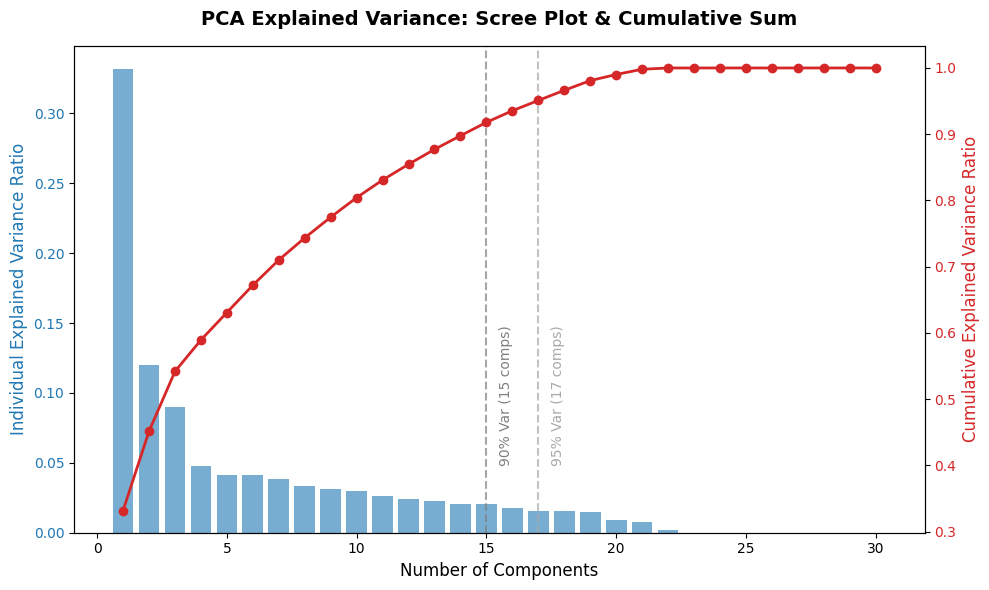

Saved scree_plot.png


In [4]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#1f77b4'
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Individual Explained Variance Ratio', color=color, fontsize=12)
bars = ax1.bar(range(1, len(explained_variance) + 1), explained_variance, color=color, alpha=0.6, align='center', label='Individual')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Cumulative Explained Variance Ratio', color=color, fontsize=12)
line = ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color=color, marker='o', linewidth=2, label='Cumulative')
ax2.tick_params(axis='y', labelcolor=color)

# Draw vertical lines for thresholds
ax1.axvline(x=n_comp_90, color='gray', linestyle='--', alpha=0.7)
ax1.text(n_comp_90 + 0.5, 0.05, f'90% Var ({n_comp_90} comps)', color='gray', rotation=90)

ax1.axvline(x=n_comp_95, color='darkgray', linestyle='--', alpha=0.7)
ax1.text(n_comp_95 + 0.5, 0.05, f'95% Var ({n_comp_95} comps)', color='darkgray', rotation=90)

plt.title('PCA Explained Variance: Scree Plot & Cumulative Sum', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved scree_plot.png")


## Step 5 - Reduce Dimensions to 2 and 3 Components

In [5]:
pca_2 = PCA(n_components=2, random_state=SEED)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_3 = PCA(n_components=3, random_state=SEED)
X_pca_3 = pca_3.fit_transform(X_scaled)

print("2D Projection shape:", X_pca_2.shape)
print("3D Projection shape:", X_pca_3.shape)


2D Projection shape: (7043, 2)
3D Projection shape: (7043, 3)


## Step 6 - Visualize Transformed 2D PCA Space

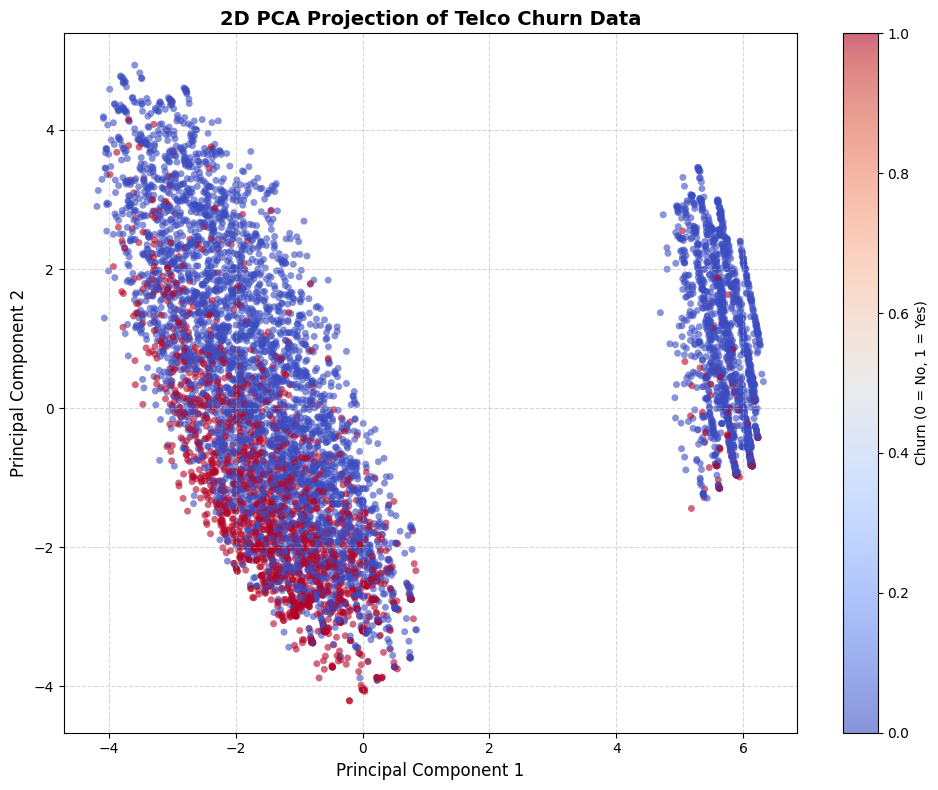

Saved pca_2d.png


In [6]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y_all, cmap='coolwarm', alpha=0.6, edgecolors='none', s=25)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('2D PCA Projection of Telco Churn Data', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Churn (0 = No, 1 = Yes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pca_2d.png")


## Step 7 - Visualize Transformed 3D PCA Space

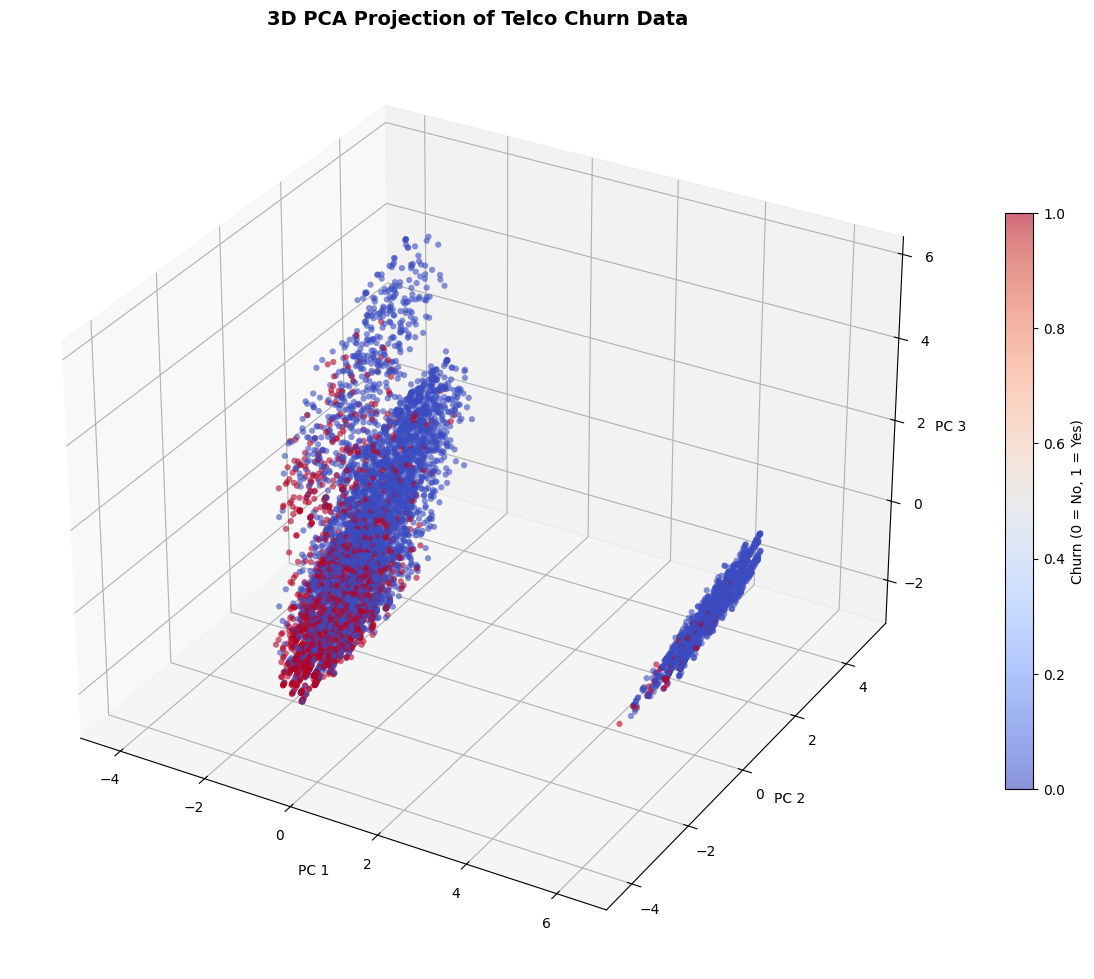

Saved pca_3d.png


In [7]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=y_all, cmap='coolwarm', alpha=0.6, edgecolors='none', s=20)
ax.set_xlabel('PC 1', fontsize=10)
ax.set_ylabel('PC 2', fontsize=10)
ax.set_zlabel('PC 3', fontsize=10)
ax.set_title('3D PCA Projection of Telco Churn Data', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Churn (0 = No, 1 = Yes)', ax=ax, shrink=0.6)
plt.tight_layout()
plt.savefig('pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved pca_3d.png")


## Step 8 - Analyze Principal Component Loadings

In [8]:
loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_scaled.columns
)

print("Top 10 strongest loadings for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))
print("\nTop 10 strongest loadings for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(10))
print("\nTop 10 strongest loadings for PC3:")
print(loadings['PC3'].abs().sort_values(ascending=False).head(10))

loadings.to_csv('loadings.csv')
print("\nSaved loadings.csv")


Top 10 strongest loadings for PC1:
StreamingMovies_No internet service     0.302314
InternetService_No                      0.302314
DeviceProtection_No internet service    0.302314
StreamingTV_No internet service         0.302314
OnlineBackup_No internet service        0.302314
OnlineSecurity_No internet service      0.302314
TechSupport_No internet service         0.302314
MonthlyCharges                          0.282448
TotalCharges                            0.184903
StreamingMovies_Yes                     0.180038
Name: PC1, dtype: float64

Top 10 strongest loadings for PC2:
tenure                                   0.437960
TotalCharges                             0.376464
Contract_Two year                        0.352777
Partner_Yes                              0.261468
PaymentMethod_Electronic check           0.214026
DeviceProtection_Yes                     0.193984
TechSupport_Yes                          0.191928
Dependents_Yes                           0.185836
MultipleLines

## Step 9 - Plot Feature Loadings

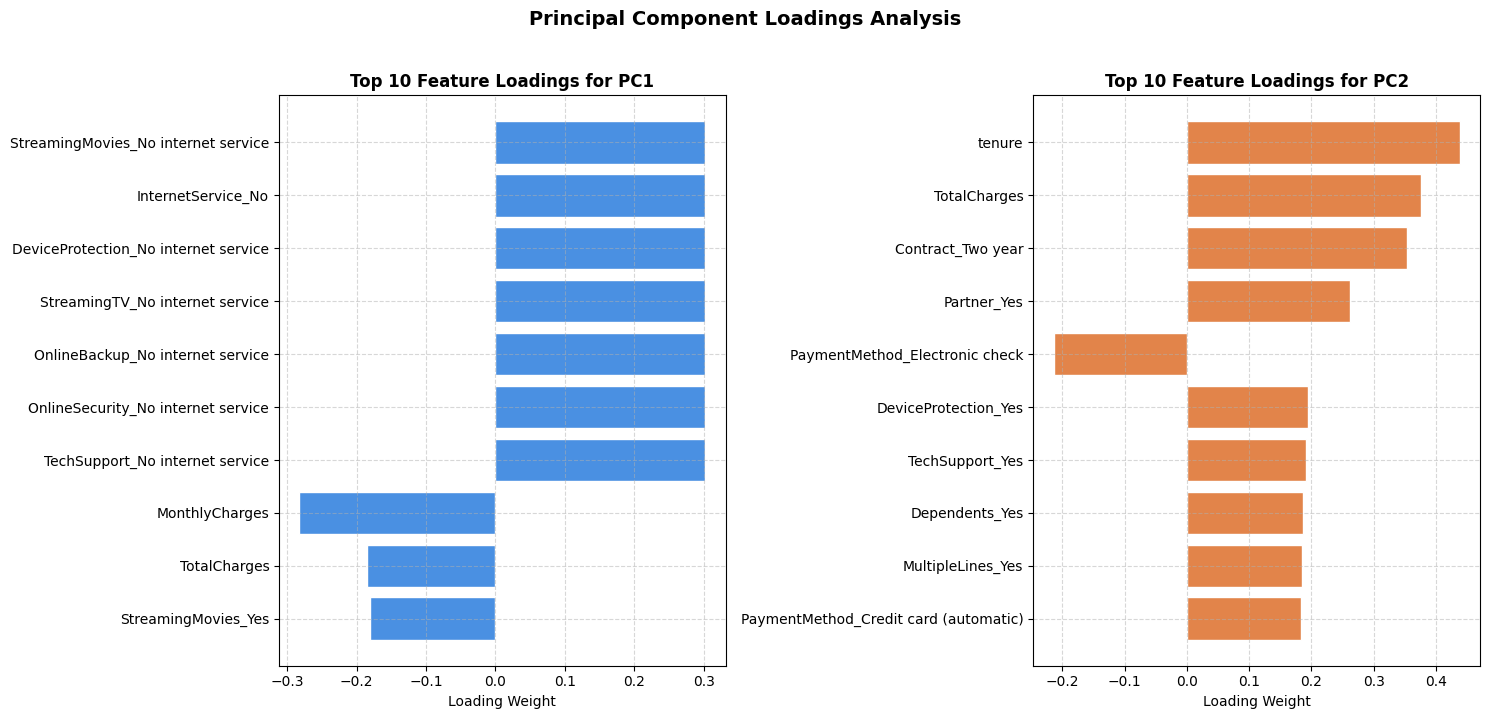

Saved loadings.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# PC1 loadings
top_pc1 = loadings['PC1'].sort_values(key=abs, ascending=False).head(10)
axes[0].barh(top_pc1.index, top_pc1.values, color='#4a90e2', edgecolor='white')
axes[0].set_title('Top 10 Feature Loadings for PC1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loading Weight')
axes[0].invert_yaxis()
axes[0].grid(True, linestyle='--', alpha=0.5)

# PC2 loadings
top_pc2 = loadings['PC2'].sort_values(key=abs, ascending=False).head(10)
axes[1].barh(top_pc2.index, top_pc2.values, color='#e2844a', edgecolor='white')
axes[1].set_title('Top 10 Feature Loadings for PC2', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loading Weight')
axes[1].invert_yaxis()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Principal Component Loadings Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved loadings.png")


## Step 10 - Compare Model Performance Before vs After PCA

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pca_90 = PCA(n_components=0.90, random_state=SEED)
X_pca_90 = pca_90.fit_transform(X_scaled)
print(f"PCA 90% variance shape: {X_pca_90.shape}")

feature_sets = {
    'All Features': X_scaled.values,
    'PCA (2 Comps)': X_pca_2,
    'PCA (3 Comps)': X_pca_3,
    f'PCA (90% Var, {X_pca_90.shape[1]} Comps)': X_pca_90
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED)
}

results = []
for f_name, X_data in feature_sets.items():
    for m_name, model in models.items():
        roc_scores = cross_val_score(model, X_data, y_all, cv=cv, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_data, y_all, cv=cv, scoring='accuracy')
        results.append({
            'Feature Set': f_name,
            'Model': m_name,
            'ROC-AUC Mean': roc_scores.mean(),
            'ROC-AUC Std': roc_scores.std(),
            'Accuracy Mean': acc_scores.mean(),
            'Accuracy Std': acc_scores.std()
        })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

results_df.to_csv('performance_comparison.csv', index=False)
print("\nSaved performance_comparison.csv")


PCA 90% variance shape: (7043, 15)


            Feature Set               Model  ROC-AUC Mean  ROC-AUC Std  Accuracy Mean  Accuracy Std
           All Features Logistic Regression        0.8451       0.0133         0.8049        0.0110
           All Features       Random Forest        0.8440       0.0119         0.7954        0.0113
          PCA (2 Comps) Logistic Regression        0.7981       0.0147         0.7701        0.0115
          PCA (2 Comps)       Random Forest        0.8153       0.0166         0.7796        0.0108
          PCA (3 Comps) Logistic Regression        0.8230       0.0126         0.7862        0.0112
          PCA (3 Comps)       Random Forest        0.8270       0.0136         0.7879        0.0121
PCA (90% Var, 15 Comps) Logistic Regression        0.8355       0.0126         0.7982        0.0141
PCA (90% Var, 15 Comps)       Random Forest        0.8307       0.0148         0.7865        0.0144

Saved performance_comparison.csv


## Step 11 - Plot Performance Comparison

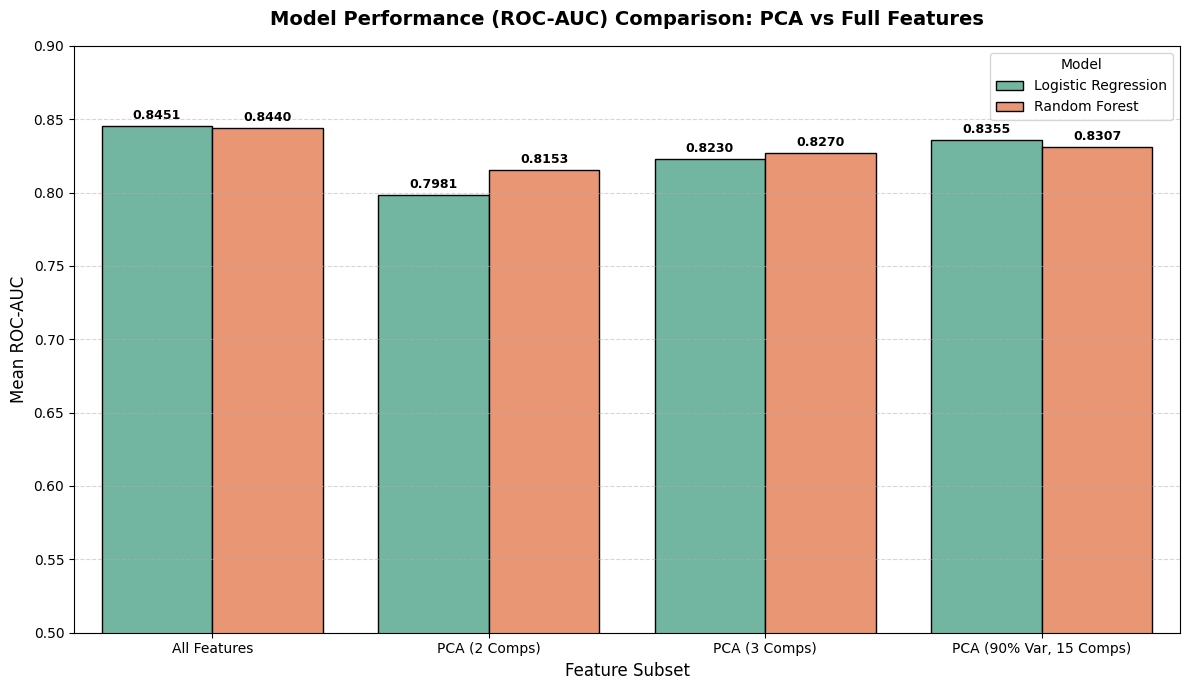

Saved before_after_comparison.png


In [11]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=results_df,
    x='Feature Set',
    y='ROC-AUC Mean',
    hue='Model',
    palette='Set2',
    edgecolor='black'
)
plt.title('Model Performance (ROC-AUC) Comparison: PCA vs Full Features', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Mean ROC-AUC', fontsize=12)
plt.xlabel('Feature Subset', fontsize=12)
plt.ylim(0.5, 0.9)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0.0:
        ax.annotate(f'{h:.4f}', (p.get_x() + p.get_width()/2., h),
                    ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved before_after_comparison.png")
